# Multi-Element Discrete Source Method
This simulates the thickness and displacement of a main wing and a deflected flap using point sources on the local chordlines and collocation points on the upper surfaces. Both elements are thick, symmetric airfoils.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path

# ==========================================
# 1. PARAMETERS
# ==========================================
N_main = 40          # Panels for main wing
N_flap = 20          # Panels for flap
N_total = N_main + N_flap
U_inf = 1.0
alpha_wind = np.radians(0) # Keep at 0 for standard source method

# Flap Geometry Controls
flap_chord = 0.4
flap_deflection = np.radians(-30)  # Tilt flap down 15 degrees
flap_shift_x = 0.9                 # Attach near trailing edge
flap_shift_y = -0.05               # Slight vertical drop

# ==========================================
# 2. AIRFOIL MATH FUNCTIONS (NACA 0015)
# ==========================================
def naca0015_thickness(x):
    t = 0.15
    x = np.clip(x, 0, 1)
    return 5 * t * (0.2969 * np.sqrt(x) - 0.1260 * x - 0.3516 * x**2 + 0.2843 * x**3 - 0.1015 * x**4)

def naca0015_dzdx(x):
    t = 0.15
    x = np.clip(x, 1e-6, 1)
    return 5 * t * (0.5 * 0.2969 / np.sqrt(x) - 0.1260 - 2 * 0.3516 * x + 3 * 0.2843 * x**2 - 4 * 0.1015 * x**3)

def rotate_2d(x, z, angle):
    xr = x * np.cos(angle) - z * np.sin(angle)
    zr = x * np.sin(angle) + z * np.cos(angle)
    return xr, zr


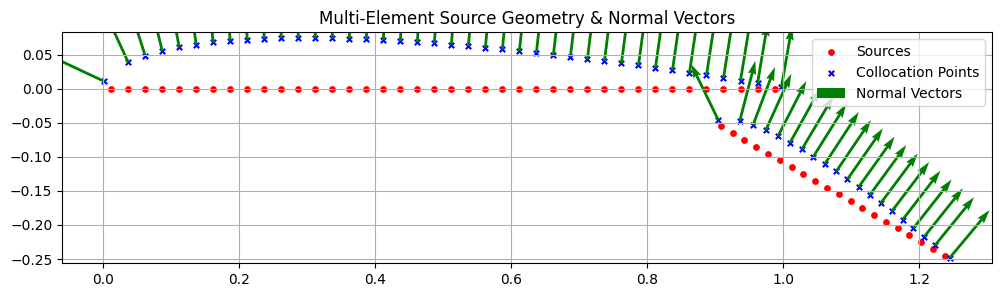

In [2]:
# ==========================================
# 3. BUILD MAIN WING GEOMETRY
# ==========================================
x_nodes_main = np.linspace(0, 1, N_main+1)
x_src_main = 0.5 * (x_nodes_main[:-1] + x_nodes_main[1:])
z_src_main = np.zeros(N_main)

x_col_main = np.copy(x_src_main)
x_col_main[0] = x_nodes_main[0] + 0.1 * (x_nodes_main[1] - x_nodes_main[0])
x_col_main[-1] = x_nodes_main[-1] - 0.1 * (x_nodes_main[-1] - x_nodes_main[-2])
z_col_main = naca0015_thickness(x_col_main)

dzdx_main = naca0015_dzdx(x_col_main)
mag_main = np.sqrt(1 + dzdx_main**2)
nx_main = -dzdx_main / mag_main
nz_main = 1.0 / mag_main
tx_main = 1.0 / mag_main
tz_main = dzdx_main / mag_main

# ==========================================
# 4. BUILD FLAP GEOMETRY (AND ROTATE IT)
# ==========================================
x_nodes_flap = np.linspace(0, flap_chord, N_flap+1)
x_src_flap_local = 0.5 * (x_nodes_flap[:-1] + x_nodes_flap[1:])
z_src_flap_local = np.zeros(N_flap)

x_col_flap_local = np.copy(x_src_flap_local)
x_col_flap_local[0] = x_nodes_flap[0] + 0.1 * (x_nodes_flap[1] - x_nodes_flap[0])
x_col_flap_local[-1] = x_nodes_flap[-1] - 0.1 * (x_nodes_flap[-1] - x_nodes_flap[-2])

# Scale the thickness by the flap chord
z_col_flap_local = flap_chord * naca0015_thickness(x_col_flap_local / flap_chord)
dzdx_flap = naca0015_dzdx(x_col_flap_local / flap_chord)

mag_flap = np.sqrt(1 + dzdx_flap**2)
nx_flap_local = -dzdx_flap / mag_flap
nz_flap_local = 1.0 / mag_flap
tx_flap_local = 1.0 / mag_flap
tz_flap_local = dzdx_flap / mag_flap

# Apply Rotation to Flap Points and Vectors
x_src_flap_rot, z_src_flap_rot = rotate_2d(x_src_flap_local, z_src_flap_local, flap_deflection)
x_col_flap_rot, z_col_flap_rot = rotate_2d(x_col_flap_local, z_col_flap_local, flap_deflection)
nx_flap_rot, nz_flap_rot = rotate_2d(nx_flap_local, nz_flap_local, flap_deflection)
tx_flap_rot, tz_flap_rot = rotate_2d(tx_flap_local, tz_flap_local, flap_deflection)

# Apply Translation to Flap Points (Vectors do not translate)
x_src_flap = x_src_flap_rot + flap_shift_x
z_src_flap = z_src_flap_rot + flap_shift_y
x_col_flap = x_col_flap_rot + flap_shift_x
z_col_flap = z_col_flap_rot + flap_shift_y
nx_flap, nz_flap = nx_flap_rot, nz_flap_rot
tx_flap, tz_flap = tx_flap_rot, tz_flap_rot

# Combine into Global Arrays
x_src = np.concatenate([x_src_main, x_src_flap])
z_src = np.concatenate([z_src_main, z_src_flap])
x_col = np.concatenate([x_col_main, x_col_flap])
z_col = np.concatenate([z_col_main, z_col_flap])
nx = np.concatenate([nx_main, nx_flap])
nz = np.concatenate([nz_main, nz_flap])
tx = np.concatenate([tx_main, tx_flap])
tz = np.concatenate([tz_main, tz_flap])

plt.figure(figsize=(12, 3))
plt.scatter(x_src, z_src, color='red', marker='o', s=15, label='Sources')
plt.scatter(x_col, z_col, color='blue', marker='x', s=15, label='Collocation Points')
plt.quiver(x_col, z_col, nx, nz, color='green', scale=15, width=0.003, label='Normal Vectors')
plt.axis('equal')
plt.title('Multi-Element Source Geometry & Normal Vectors')
plt.legend()
plt.grid(True)
plt.show()


In [3]:
# ==========================================
# 5. INFLUENCE MATRIX & SOLVER
# ==========================================
A = np.zeros((N_total, N_total))
b = np.zeros(N_total)

for i in range(N_total):
    b[i] = -(U_inf * np.cos(alpha_wind) * nx[i] + U_inf * np.sin(alpha_wind) * nz[i])

    for j in range(N_total):
        delx = x_col[i] - x_src[j]
        delz = z_col[i] - z_src[j]
        r_squared = max(delx**2 + delz**2, 1e-10)

        u_ij = (1 / (2 * np.pi)) * (delx / r_squared)
        w_ij = (1 / (2 * np.pi)) * (delz / r_squared)

        A[i, j] = (u_ij * nx[i]) + (w_ij * nz[i])

sigma = np.linalg.solve(A, b)
print(f"Net Source Flow (Should be ~0): {np.sum(sigma):.5f}")


Net Source Flow (Should be ~0): -0.31048


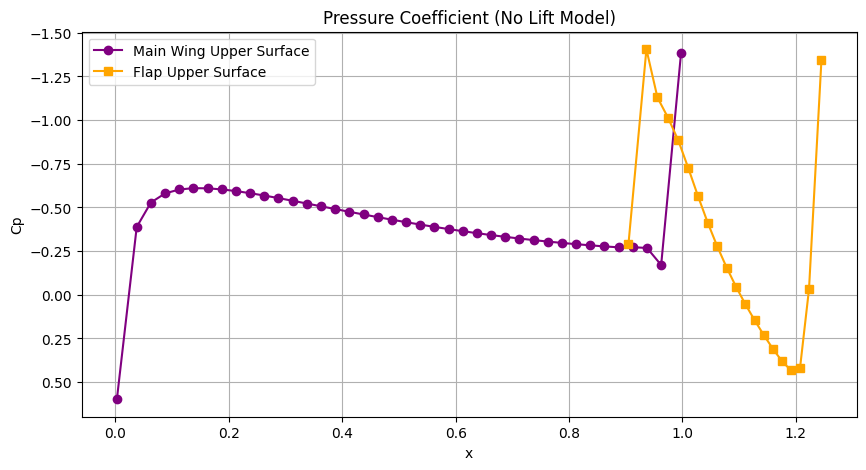

In [4]:
# ==========================================
# 6. VELOCITY AND CP DISTRIBUTION
# ==========================================
Vt = np.zeros(N_total)

for i in range(N_total):
    Vt[i] = U_inf * np.cos(alpha_wind) * tx[i] + U_inf * np.sin(alpha_wind) * tz[i]
    for j in range(N_total):
        delx = x_col[i] - x_src[j]
        delz = z_col[i] - z_src[j]
        r_squared = max(delx**2 + delz**2, 1e-10)

        u_ij = (1 / (2 * np.pi)) * (delx / r_squared)
        w_ij = (1 / (2 * np.pi)) * (delz / r_squared)

        Vt[i] += sigma[j] * (u_ij * tx[i] + w_ij * tz[i])

Cp = 1 - (Vt / U_inf)**2

plt.figure(figsize=(10, 5))
plt.plot(x_col[:N_main], Cp[:N_main], '-o', color='purple', label='Main Wing Upper Surface')
plt.plot(x_col[N_main:], Cp[N_main:], '-s', color='orange', label='Flap Upper Surface')
plt.gca().invert_yaxis()
plt.xlabel('x')
plt.ylabel('Cp')
plt.title('Pressure Coefficient (No Lift Model)')
plt.legend()
plt.grid(True)
plt.show()


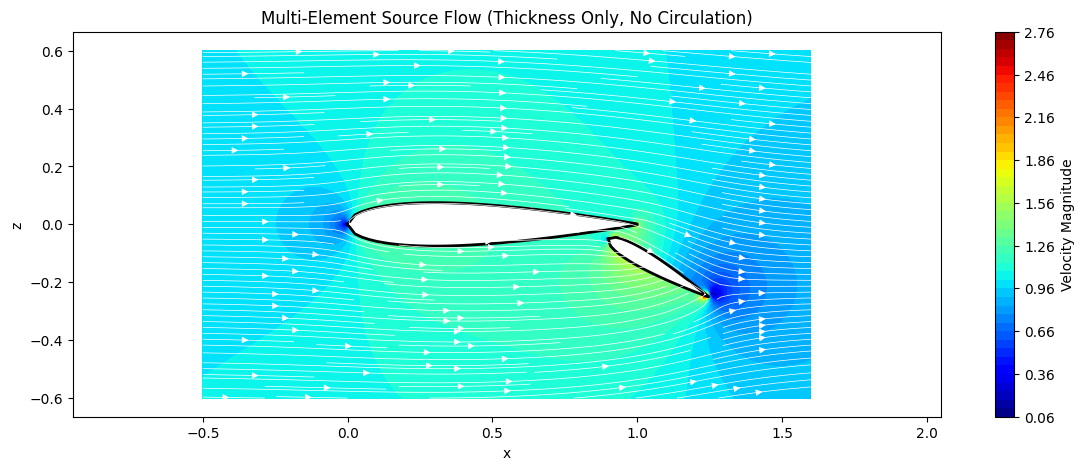

In [5]:
# ==========================================
# 7. STREAMLINES & MASKED VELOCITY CONTOURS
# ==========================================
X, Z = np.meshgrid(np.linspace(-0.5, 1.6, 200), np.linspace(-0.6, 0.6, 150))
U = U_inf * np.cos(alpha_wind) * np.ones_like(X)
W = U_inf * np.sin(alpha_wind) * np.ones_like(Z)

for j in range(N_total):
    delx = X - x_src[j]
    delz = Z - z_src[j]
    r_squared = delx**2 + delz**2
    r_squared[r_squared < 1e-5] = 1e-5

    U += (sigma[j] / (2 * np.pi)) * (delx / r_squared)
    W += (sigma[j] / (2 * np.pi)) * (delz / r_squared)

vel_mag = np.sqrt(U**2 + W**2)

# Mask out the interior of the airfoils
x_m_path = np.concatenate([x_nodes_main, x_nodes_main[::-1]])
z_m_path = np.concatenate([naca0015_thickness(x_nodes_main), -naca0015_thickness(x_nodes_main)[::-1]])
main_path = Path(np.column_stack((x_m_path, z_m_path)))

x_f_path_loc = np.concatenate([x_nodes_flap, x_nodes_flap[::-1]])
z_f_path_loc = np.concatenate([
    flap_chord * naca0015_thickness(x_nodes_flap/flap_chord),
    -flap_chord * naca0015_thickness(x_nodes_flap[::-1]/flap_chord)
])
x_f_rot, z_f_rot = rotate_2d(x_f_path_loc, z_f_path_loc, flap_deflection)
flap_path = Path(np.column_stack((x_f_rot + flap_shift_x, z_f_rot + flap_shift_y)))

points = np.column_stack((X.flatten(), Z.flatten()))
mask = main_path.contains_points(points) | flap_path.contains_points(points)
vel_mag[mask.reshape(X.shape)] = np.nan

plt.figure(figsize=(14, 5))
contour = plt.contourf(X, Z, vel_mag, levels=50, cmap='jet')
plt.colorbar(contour, label='Velocity Magnitude')

# Draw the boundaries
plt.plot(x_m_path, z_m_path, '-k', linewidth=2)
plt.plot(x_f_rot + flap_shift_x, z_f_rot + flap_shift_y, '-k', linewidth=2)

plt.streamplot(X, Z, U, W, density=2, color='white', linewidth=0.5)
plt.axis('equal')
plt.title('Multi-Element Source Flow (Thickness Only, No Circulation)')
plt.xlabel('x')
plt.ylabel('z')
plt.show()
